# 07 — Compounding: реинвест прибыли (сложный процент)

До сих пор портфель был $20/сделку ФИКС (без реинвеста) → почти линейный рост.
Идея пользователя: реинвестировать заработанное → растёт либо ОБЪЁМ сделки, либо
ЧИСЛО одновременных слотов. Сложный процент.

**Три модели (честный event-driven сим: кэш + открытые позиции, реализация на выходе):**
- **A. Fixed** — $20/сделку, ≤50 слотов (база iter03/05, без реинвеста).
- **B. Compound SIZE** — нотионал = f·equity (f=2%, старт ≈$20), ≤50 слотов. Объём растёт.
- **C. Compound SLOTS** — $20/сделку фикс, слотов = equity/$20 (растёт число параллельных).

Полная вселенная 173, −7%/15m, scale-in net PnL (из dump_trades.parquet).
Ограничения: нельзя превысить наличный кэш; нет MTM внутри сделки (реализация на выходе).

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path
import heapq
D=pd.read_parquet(Path("_out")/"dump_trades.parquet").sort_values("entry").reset_index(drop=True)
print(f"trades: {len(D)}  span {D.entry.min():%Y-%m} .. {D.entry.max():%Y-%m}")
span=(D.entry.max()-D.entry.min()).days/365.25

def sim(df, mode, START=1000.0, base=20.0, frac=0.02, max_slots_fixed=50):
    df=df.sort_values("entry").reset_index(drop=True)
    entry=df.entry.to_numpy(); exit_=df.exit_ts.to_numpy(); pnl=df.pnl.to_numpy()
    cash=START; deployed=0.0
    openh=[]   # (exit_ts, notional, pnl)
    eq_t=[]; eq_v=[]; peak=START; maxdd=0.0; taken=0; skipped=0; sizes=[]
    def equity(): return cash+deployed
    for i in range(len(df)):
        now=entry[i]
        while openh and openh[0][0]<=now:
            _,notional,pn=heapq.heappop(openh)
            ret=notional*(1+pn); cash+=ret; deployed-=notional
            peak=max(peak,equity()); maxdd=min(maxdd,equity()/peak-1)
            eq_t.append(now); eq_v.append(equity())
        # sizing + capacity
        if mode=="A":   notional=base;            cap=max_slots_fixed
        elif mode=="B": notional=frac*equity();   cap=max_slots_fixed
        elif mode=="C": notional=base;            cap=int(equity()//base)
        if len(openh)<cap and cash>=notional and notional>0:
            cash-=notional; deployed+=notional
            heapq.heappush(openh,(exit_[i],notional,pnl[i])); taken+=1; sizes.append(notional)
        else: skipped+=1
    for ex,notional,pn in sorted(openh):
        cash+=notional*(1+pn); deployed-=notional
        peak=max(peak,cash); maxdd=min(maxdd,cash/peak-1)
        eq_t.append(ex); eq_v.append(cash)
    final=cash
    return dict(final=final, ret=final/START-1, cagr=(final/START)**(1/span)-1,
                maxdd=maxdd, taken=taken, skipped=skipped,
                avg_size=np.mean(sizes), last_size=sizes[-1] if sizes else 0,
                eq_t=np.array(eq_t), eq_v=np.array(eq_v))

trades: 4286  span 2024-01 .. 2026-04


In [2]:
print(f"span = {span:.2f} years\n")
res={}
for mode,desc in [("A","Fixed $20, <=50 slots (no reinvest)"),
                  ("B","Compound SIZE (2% equity/trade), <=50 slots"),
                  ("C","Compound SLOTS ($20 fixed, slots=equity/20)")]:
    r=sim(D,mode); res[mode]=r
    print(f"=== {mode}: {desc} ===")
    print(f"  final ${r['final']:,.0f}  total {r['ret']*100:+,.0f}%  CAGR {r['cagr']*100:+.1f}%/yr"
          f"  realized maxDD {r['maxdd']*100:.1f}%")
    print(f"  taken {r['taken']}  skipped {r['skipped']} ({r['skipped']/(r['taken']+r['skipped'])*100:.0f}%)"
          f"  avg size ${r['avg_size']:.0f}  last size ${r['last_size']:,.0f}\n")

span = 2.32 years

=== A: Fixed $20, <=50 slots (no reinvest) ===
  final $1,960  total +96%  CAGR +33.7%/yr  realized maxDD -6.4%
  taken 2532  skipped 1754 (41%)  avg size $20  last size $20

=== B: Compound SIZE (2% equity/trade), <=50 slots ===
  final $2,465  total +147%  CAGR +47.6%/yr  realized maxDD -7.8%
  taken 2515  skipped 1771 (41%)  avg size $32  last size $49

=== C: Compound SLOTS ($20 fixed, slots=equity/20) ===
  final $2,242  total +124%  CAGR +41.7%/yr  realized maxDD -9.3%
  taken 2899  skipped 1387 (32%)  avg size $20  last size $20



[saved] notebooks\dump\_out\07_compounding.png


WindowsPath('C:/projects/researchlab/notebooks/dump/_out/07_compounding.png')

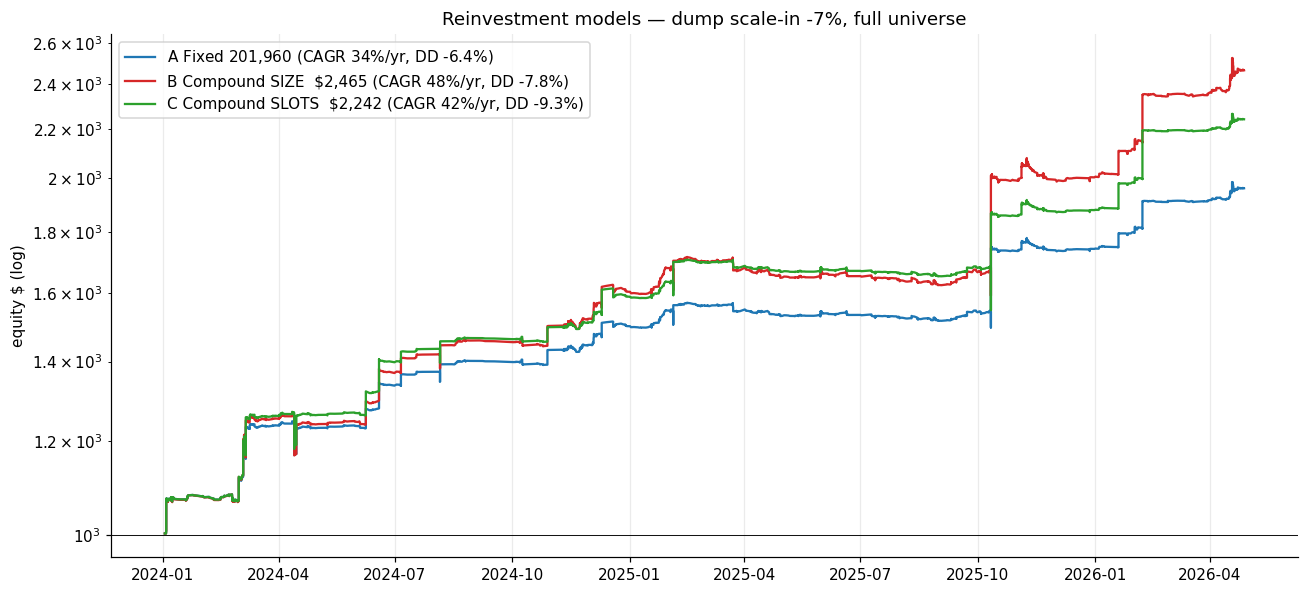

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5.5))
cols={"A":"#1f77b4","B":"#d62728","C":"#2ca02c"}
names={"A":"A Fixed $20","B":"B Compound SIZE","C":"C Compound SLOTS"}
for m in ("A","B","C"):
    r=res[m]
    plt.plot(r["eq_t"],r["eq_v"],color=cols[m],
             label=f"{names[m]}  ${r['final']:,.0f} (CAGR {r['cagr']*100:.0f}%/yr, DD {r['maxdd']*100:.1f}%)")
plt.yscale("log"); plt.axhline(1000,color="k",lw=.6)
plt.ylabel("equity $ (log)"); plt.title("Reinvestment models — dump scale-in -7%, full universe")
plt.legend(); show("07_compounding")

**Замечание:** ось Y логарифмическая — на ней сложный процент = прямая линия.
Модель A (фикс) гнётся вниз в лог-шкале (линейный рост). B и C должны идти прямее
(экспонента). Сравни CAGR и maxDD: реинвест поднимает доходность, НО усиливает
просадку (больше денег в риске), а compounding в один и тот же кластерный дамп =
тот самый коррелированный хвост.

In [4]:
# BONUS: classifier filter + compounding, on TEST window (honest OOS preds)
te=pd.read_parquet(Path("_out")/"dump_test_pred.parquet").sort_values("entry").reset_index(drop=True)
spanT=(te.entry.max()-te.entry.min()).days/365.25
# reuse sim() but recompute CAGR with the test-window span
def sim_window(df,mode,**kw):
    s=(df.entry.max()-df.entry.min()).days/365.25
    r=sim(df,mode,**kw); r['cagr']=(r['final']/1000.0)**(1/s)-1; r['span']=s
    return r
print(f"TEST window {te.entry.min():%Y-%m} .. {te.entry.max():%Y-%m} ({spanT:.2f}y), n={len(te)}\n")
med=te.pred.median()
for tag,df in [("trade-ALL (test)",te),("FILTER top-50% (pred>median)",te[te.pred>med])]:
    for mode in ("A","B","C"):
        r=sim_window(df.copy(),mode)
        print(f"  {tag:32} {mode}: final ${r['final']:,.0f}  total {r['ret']*100:+,.0f}%  "
              f"CAGR {r['cagr']*100:+.0f}%/yr  maxDD {r['maxdd']*100:.1f}%  (taken {r['taken']})")
    print()

TEST window 2025-02 .. 2026-04 (1.23y), n=1715

  trade-ALL (test)                 A: final $1,451  total +45%  CAGR +35%/yr  maxDD -6.9%  (taken 1184)
  trade-ALL (test)                 B: final $1,525  total +52%  CAGR +41%/yr  maxDD -6.9%  (taken 1179)
  trade-ALL (test)                 C: final $1,501  total +50%  CAGR +39%/yr  maxDD -6.9%  (taken 1223)

  FILTER top-50% (pred>median)     A: final $1,471  total +47%  CAGR +37%/yr  maxDD -4.7%  (taken 616)
  FILTER top-50% (pred>median)     B: final $1,558  total +56%  CAGR +44%/yr  maxDD -5.0%  (taken 614)
  FILTER top-50% (pred>median)     C: final $1,526  total +53%  CAGR +41%/yr  maxDD -4.7%  (taken 654)



## Как читать
- **A vs B vs C** — фикс vs реинвест-объёмом vs реинвест-слотами. Лог-шкала:
  прямая = экспонента (сложный процент). Смотри CAGR и maxDD вместе.
- **Реинвест ≠ бесплатный обед:** растёт и доходность, и просадка (больше капитала
  под риском, compounding в коррелированные кластеры). Это тот же short-vol хвост,
  что мы стрессили в iter04 — теперь он бьёт по бОльшему капиталу.
- **Бонус (фильтр+compound на тесте):** даёт ли классификатор более гладкий
  сложный процент (выше CAGR / ниже DD), чем торговать всё.

*Verdict после прогона.*

## VERDICT (iter 07)

**Сложный процент работает, но усиливает риск.** Полная вселенная, 2.32г:
- A Fixed $20 (без реинвеста): +96%, CAGR +33.7%/год, maxDD −6.4%.
- B Compound SIZE (2% капитала/сделку): +147%, **CAGR +47.6%**, maxDD −7.8%. Лучший баланс.
- C Compound SLOTS ($20, слотов=экв/20): +124%, CAGR +41.7%, **maxDD −9.3%** (хуже всех).

**Урок:** реинвест поднимает CAGR, но углубляет DD. C хуже всего по DD — больше
одновременных позиций набивается в КОРРЕЛИРОВАННЫЕ кластеры дампов (тот же
short-vol хвост из iter04, теперь по большему числу сделок). B (рост объёма)
не плодит коррелированную экспозицию → лучший CAGR/DD.

**Синтез с классификатором (тест OOS):** фильтр top-50% + Compound SIZE даёт
CAGR +44% при maxDD −5.0% vs trade-all +41%/−6.9% — выше доходность И ниже
просадка одновременно. Фильтр чистит поток → реинвест на более гладком ряду.

**Оговорки:** f=2% — рычаг (больше f = глубже DD); compounding в коррелированные
кластеры усиливает tail; maxDD реализованный (MTM глубже); skip 41%.

**Дальше:** walk-forward классификатора (pump-14); regime-фильтр кластеров; порт в strategies/бот.